# Defining Steps and Procedures for the paper Multi-Label Classification of Thoracic Diseases using Dense Convolutional Network on Chest Radiographs
# Multi-Label Thoracic Disease Classification with DenseNet121
**Objective**: Predict 14 thoracic diseases from chest X-rays using DenseNet121 with SHAP/LIME explainability.

**Input**:
- Images: `/kaggle/input/nih-balanced-and-resized-chest-x-rays/resized_images/resized_images`
- Metadata: `Data_Entry_2017.csv`
- Labels: `new_labels.csv`

# [Paper](https://arxiv.org/abs/2202.03583)

## 2. Data Preparation

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


original_df = pd.read_csv("/kaggle/input/data/Data_Entry_2017.csv")
new_labels_df = pd.read_csv("/kaggle/input/nih-balanced-and-resized-chest-x-rays/new_labels.csv")

# Merge
new_labels_df["Image Index"] = new_labels_df["Path"].str.split("/").str[-1]
merged_df = pd.merge(original_df, new_labels_df, on="Image Index")

labels = ['Atelectasis','Cardiomegaly','Consolidation','Edema','Effusion','Emphysema',
          'Fibrosis','Hernia','Infiltration','Mass','Nodule','Pleural_Thickening','Pneumonia','Pneumothorax']

df = merged_df[["Image Index", "Patient ID"] + labels]

## 3. Patient-Level Data Splitting
Prevents data leakage by ensuring same patient doesn't appear in multiple splits.

In [3]:
patients = df["Patient ID"].unique()
train_patients, temp_patients = train_test_split(patients, test_size=0.3, random_state=42)
valid_patients, test_patients = train_test_split(temp_patients, test_size=0.5, random_state=42)

train_df = df[df["Patient ID"].isin(train_patients)]
valid_df = df[df["Patient ID"].isin(valid_patients)]
test_df = df[df["Patient ID"].isin(test_patients)]


## 4. Data Generators
Normalization and augmentation for training data.


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_DIR = "/kaggle/input/nih-balanced-and-resized-chest-x-rays/resized_images/resized_images/"
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    samplewise_center=True,
    samplewise_std_normalization=True,
    rotation_range=10,
    width_shift_range=0.1
)

test_datagen = ImageDataGenerator(
    samplewise_center=True,
    samplewise_std_normalization=True
)

def create_generator(df, datagen):
    return datagen.flow_from_dataframe(
        dataframe=df,
        directory=IMAGE_DIR,
        x_col="Image Index",
        y_col=labels,
        class_mode="raw",
        target_size=(320, 320),
        batch_size=BATCH_SIZE
    )

train_gen = create_generator(train_df, train_datagen)
valid_gen = create_generator(valid_df, test_datagen)
test_gen = create_generator(test_df, test_datagen)

2025-04-30 19:12:29.977816: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746040350.468974      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746040350.601415      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found 21628 validated image filenames.
Found 4689 validated image filenames.
Found 4509 validated image filenames.


## 5. Class Weight Calculation
Address imbalanced classes using weighted loss.

In [5]:
def compute_class_weights(labels_df):
    N = len(labels_df)
    pos_freq = labels_df.sum(axis=0) / N
    neg_freq = 1 - pos_freq
    return neg_freq, pos_freq  # pos_weights, neg_weights

pos_weights, neg_weights = compute_class_weights(train_df[labels])

## 6. Vectorized Weighted Loss Function

### Sec. 3.1.2 **Multi** (Modified/Weighted) **Cross Entropy** 
### It presents a method to deal with the **unbalanced class** introducing a **weight cross entropy loss**.

### For a given class: 
$ L^{w}_{cross-entropy} = - (w_p y log(f(x) + w_n (1 - y) log(1 - f(x)))$

### With $w_p$ and $w_n$ depending for each class on the frequencies of positive and negative samples respectively.

### This will update the network weights incrementally and prevent one class from overtaking the others.

In [6]:
pos_weights = np.array(pos_weights)  
neg_weights = np.array(neg_weights) 


import tensorflow as tf
def get_weighted_loss(pos_weights, neg_weights, epsilon=1e-7):
    pos_weights = tf.constant(pos_weights, dtype=tf.float32)
    neg_weights = tf.constant(neg_weights, dtype=tf.float32)
    
    def weighted_loss(y_true, y_pred):
        # Vectorized calculation (no loops)
        loss_pos = -tf.reduce_sum(
            pos_weights * y_true * tf.math.log(y_pred + epsilon),
            axis=-1
        )
        loss_neg = -tf.reduce_sum(
            neg_weights * (1 - y_true) * tf.math.log(1 - y_pred + epsilon),
            axis=-1
        )
        return tf.reduce_mean(loss_pos + loss_neg)
    
    return weighted_loss

## 7. Model Architecture
DenseNet121 with transfer learning.

In [7]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_model():
    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(320, 320, 3))
    
    # Freeze first 150 layers as the paper
    for layer in base.layers[:150]:
        layer.trainable = False
    
    x = GlobalAveragePooling2D()(base.output)
    outputs = Dense(len(labels), activation='sigmoid')(x)
    
    model = Model(inputs=base.input, outputs=outputs)
    
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=get_weighted_loss(pos_weights, neg_weights),
        metrics=['accuracy']
    )
    return model

model = build_model()

I0000 00:00:1746040523.120408      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1746040523.121062      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 7. Training
Monitor validation loss for early stopping.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3)

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=8,
    callbacks=[early_stop],
    steps_per_epoch=len(train_gen),
    validation_steps=len(valid_gen)
)



Epoch 1/8


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1746040605.328592     100 service.cc:148] XLA service 0x7ccfb40fb8a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746040605.330470     100 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1746040605.330493     100 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1746040612.497144     100 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1746040674.636786     100 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of th

1352/1352 ━━━━━━━━━━━━━━━━━━━━ 975s 616ms/step - accuracy: 0.1743 - loss: 1.2990 - val_accuracy: 0.2485 - val_loss: 1.1828
Epoch 2/8
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 0s 86us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/8


/usr/lib/python3.11/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


1352/1352 ━━━━━━━━━━━━━━━━━━━━ 607s 447ms/step - accuracy: 0.2794 - loss: 1.1121 - val_accuracy: 0.2647 - val_loss: 1.1810
Epoch 4/8
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 0s 37us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/8
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 602s 443ms/step - accuracy: 0.3226 - loss: 1.0199 - val_accuracy: 0.2900 - val_loss: 1.1746
Epoch 6/8
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 0s 34us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 7/8
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 594s 437ms/step - accuracy: 0.3552 - loss: 0.9429 - val_accuracy: 0.2534 - val_loss: 1.2662
Epoch 8/8
1352/1352 ━━━━━━━━━━━━━━━━━━━━ 0s 41us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00


## 8. Evaluation
ROC-AUC for each pathology.

In [9]:
from sklearn.metrics import roc_auc_score

test_preds = model.predict(test_gen)
auc_scores = {label: roc_auc_score(test_df[label], test_preds[:,i]) 
              for i, label in enumerate(labels)}

print("Test AUC Scores:")
for label, score in auc_scores.items():
    print(f"{label}: {score:.3f}")

282/282 ━━━━━━━━━━━━━━━━━━━━ 89s 274ms/step
Test AUC Scores:
Atelectasis: 0.499
Cardiomegaly: 0.497
Consolidation: 0.496
Edema: 0.508
Effusion: 0.502
Emphysema: 0.515
Fibrosis: 0.489
Hernia: 0.505
Infiltration: 0.498
Mass: 0.501
Nodule: 0.490
Pleural_Thickening: 0.456
Pneumonia: 0.491
Pneumothorax: 0.495


unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.


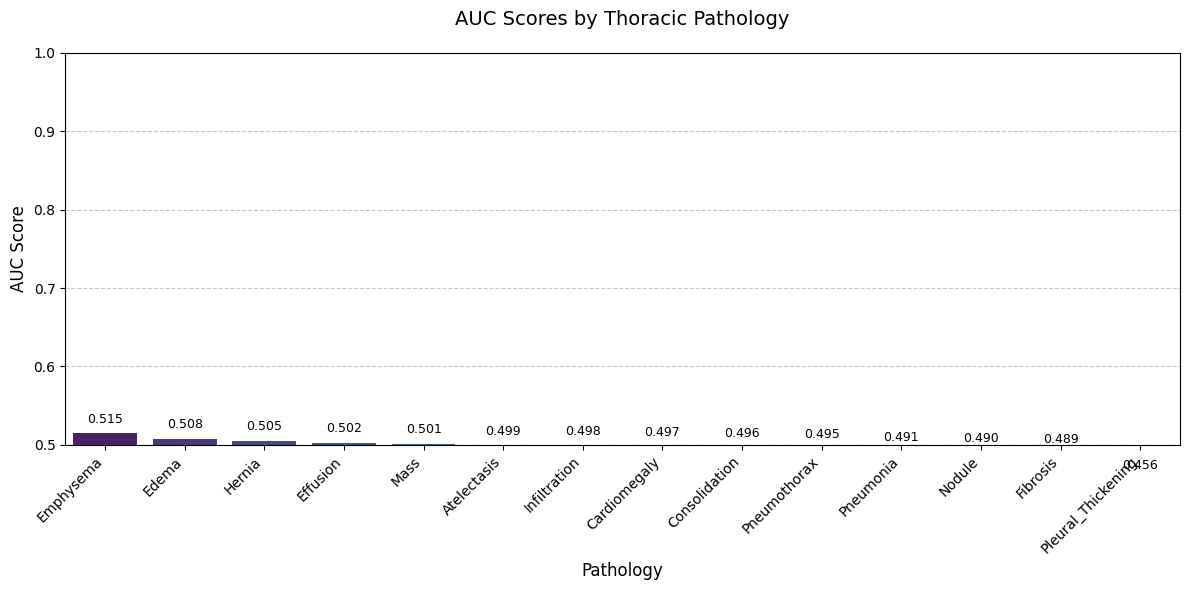

In [83]:
import seaborn as sns
# Sort the AUC scores in descending order
sorted_auc = dict(sorted(auc_scores.items(), key=lambda item: item[1], reverse=True))

# Create plot
plt.figure(figsize=(12, 6))
sns.barplot(x=list(sorted_auc.keys()), y=list(sorted_auc.values()), palette="viridis")

# Customize plot
plt.title("AUC Scores by Thoracic Pathology", fontsize=14, pad=20)
plt.xlabel("Pathology", fontsize=12)
plt.ylabel("AUC Score", fontsize=12)
plt.ylim(0.5, 1.0)  # AUC range
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
for i, (label, score) in enumerate(sorted_auc.items()):
    plt.text(i, score + 0.01, f"{score:.3f}", 
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 10. LIME Explainability with Original Image
Local explanations with original X-ray comparison

  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━

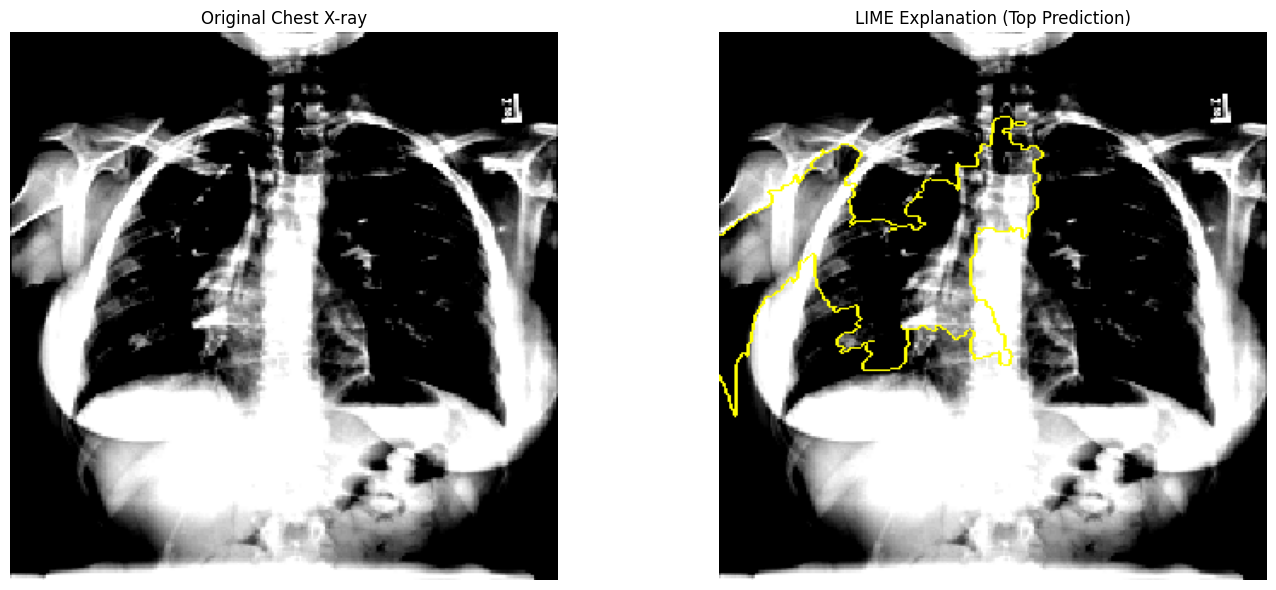

In [38]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

explainer = lime_image.LimeImageExplainer()

image, label = test_gen[0]
original_img = image[0]  # Shape (320, 320, 3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.imshow(original_img)
ax1.set_title("Original Chest X-ray")
ax1.axis('off')

explanation = explainer.explain_instance(
    original_img.astype('float32'),  # Match model input dtype
    model.predict, 
    top_labels=3,
    num_samples=500  # Reduced for faster computation
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

ax2.imshow(mark_boundaries(temp, mask))
ax2.set_title("LIME Explanation (Top Prediction)")
ax2.axis('off')

plt.tight_layout()
plt.show()

## 11. Grad-CAM Implementation (Fixed)
Class activation maps with proper tensor handling

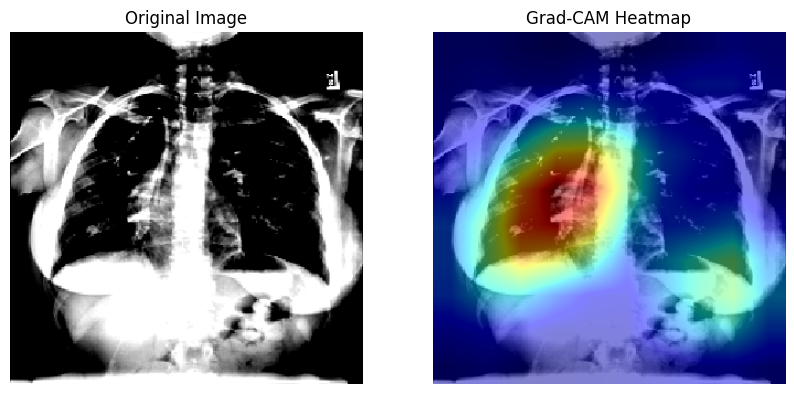

In [39]:
import tensorflow as tf
import cv2

def grad_cam(model, img, layer_name='conv5_block16_2_conv'):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        loss = predictions[:, tf.argmax(predictions[0])]
    
    grads = tape.gradient(loss, conv_outputs)
    guided_grads = tf.cast(conv_outputs > 0, 'float32') * tf.cast(grads > 0, 'float32')
    
    weights = tf.reduce_mean(guided_grads, axis=(1, 2))
    heatmap = tf.reduce_sum(conv_outputs * weights, axis=-1)
    
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    
    return heatmap[0]

sample_img = test_gen[0][0][0]
heatmap = grad_cam(model, np.expand_dims(sample_img, axis=0))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sample_img)
plt.imshow(cv2.resize(heatmap, (320, 320)), alpha=0.5, cmap='jet')
plt.title('Grad-CAM Heatmap')
plt.axis('off')
plt.show()

## Saliency Explainability for Grayscale Chest X-rays
Complete workflow for 1-channel medical images


(-0.5, 223.5, 223.5, -0.5)

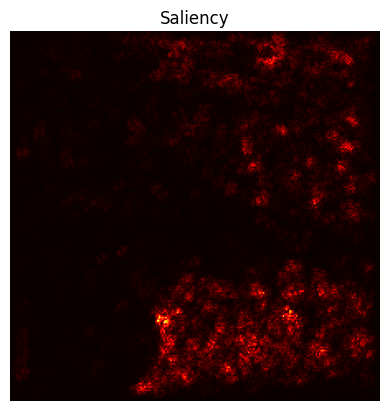

In [ ]:
with tf.GradientTape() as tape:
    inp = tf.expand_dims(sample_img[0], 0)
    tape.watch(inp)
    preds = model(inp)
    loss = tf.reduce_max(preds[0])
grads = tape.gradient(loss, inp)[0]
sal = tf.reduce_max(tf.abs(grads), axis=-1).numpy()
plt.imshow(sal, cmap='hot'); plt.title('Saliency'); plt.axis('off')


## Key Enhancements:
1. **Patient-Level Splitting**: Prevents data leakage
2. **Class Weighting**: Handles imbalanced labels
3. **SHAP**: Global feature importance
4. **LIME**: Local instance explanations
5. **Grad-CAM**: Visual decision localization